In [1]:
import sys
print(sys.version)

3.9.23 (main, Jun  5 2025, 13:40:20) 
[GCC 11.2.0]


In [1]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
# Core scverse libraries
import scanpy as sc
import anndata as ad
import scvelo as scv
# Data retrieval
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
# 手动设置绘图参数
sc.set_figure_params(
    dpi=80,
    dpi_save=300, #保存本地图像的分辨率
    facecolor="white",
    frameon=True,  #是否添加框线
    figsize=(4, 4),
    format='pdf'
                    )
# 设置全局 rcParams
plt.rcParams.update({
    'axes.spines.top': True,
    'axes.spines.right': True
})

#### 读入数据  cytotrace2---dpt拟时序

In [4]:
adata_a=sc.read_h5ad('./08_颗粒细胞亚群细分_差异分析/08_after_hb_Gr_subanndata.h5ad')

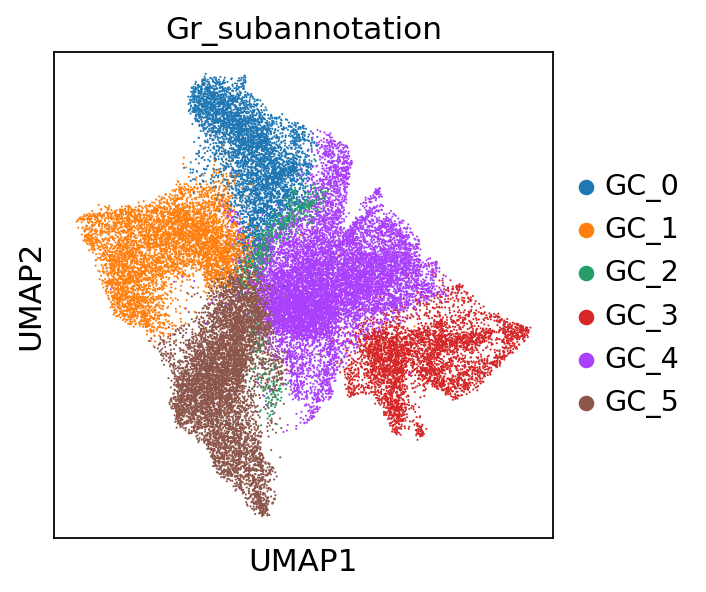

In [4]:
sc.pl.umap(adata_a,color='Gr_subannotation')

### Cytotrace2   切换kernel     再新的cytotrace专属环境中


In [1]:
### 输入数据 单细胞表达矩阵count 或者tpm cpm 不要log处理，画图可以用细胞注释文件 
from cytotrace2_py.cytotrace2_py import *

In [5]:
# 将稀疏矩阵转换为密集矩阵
dense_matrix = adata_a.layers['counts'].copy().toarray().T

# 创建 DataFrame，这里我们交换行列以使行对应基因，列对应样本
df = pd.DataFrame(dense_matrix, index=adata_a.var_names, columns=adata_a.obs_names)

# 保存为 tab 分割的文本文件
output_file = './10_cytotrace2_拟时序分析/10_gr_counts_cytotrace2_input.txt'
df.to_csv(output_file, sep='\t', index=True, header=True)

print(f"Matrix has been saved to {output_file} with genes as rows and samples as columns.")

# 将数据组合成一个 DataFrame
df = pd.DataFrame({
    'Cell_ID': adata_a.obs_names,
    'Cell_Type_Annotation':adata_a.obs['Gr_subannotation']
})

# 导出为 tab 分割的文本文件
output_file = './10_cytotrace2_拟时序分析/10_gr_cell_annotations_cytotrace2_input.txt'
df.to_csv(output_file, sep='\t', index=False)

print(f"Data has been saved to {output_file} with the required format.")

Matrix has been saved to ./10_cytotrace2_拟时序分析/10_gr_counts_cytotrace2_input.txt with genes as rows and samples as columns.
Data has been saved to ./10_cytotrace2_拟时序分析/10_gr_cell_annotations_cytotrace2_input.txt with the required format.


In [4]:
### 运行cytotrace2

input_path='./10_cytotrace2_拟时序分析/10_gr_counts_cytotrace2_input.txt'
annotation_path='/10_cytotrace2_拟时序分析/10_gr_cell_annotations_cytotrace2_input.txt'
result = cytotrace2(input_path,
                       #annotation_path = annotation_path,
                       species="mouse",
                       batch_size = 10000,
                       smooth_batch_size = 1000,
                       disable_plotting = True,
                       disable_parallelization = False,
                       max_cores = 6,
                    output_dir = './10_cytotrace2_拟时序分析/',
                       seed = 14)               

cytotrace2: Input parameters
    Input file: ./10_cytotrace2_拟时序分析/10_gr_counts_cytotrace2_input.txt
    Species: mouse
    Parallelization enabled: True
    Batch size: 10000
    Smoothing batch size: 1000
    Seed: 14
    Output directory: ./10_cytotrace2_拟时序分析/
    Plotting enabled: False
    Verbose mode enabled: True
    User-provided limit for number of cores to use: 6
cytotrace2: Loading dataset
cytotrace2: Dataset characteristics
    Number of input genes:  18144
    Number of input cells:  33475
cytotrace2: Preprocessing
cytotrace2: Running 4 prediction batch(es) sequentially using 6 cores per batch.
cytotrace2: Initiated processing batch 1/4 with 8369 cells
    13045 input genes are present in the model features.
cytotrace2: Performing initial model prediction
cytotrace2: Performing smoothing by diffusion
cytotrace2: Performing smoothing by adaptive KNN
cytotrace2: Initiated processing batch 2/4 with 8369 cells
    13045 input genes are present in the model features.
cytotrac

In [8]:
### 读入cytotrace2 res
result=pd.read_csv('./10_cytotrace2_拟时序分析/cytotrace2_results.txt',index_col=0,sep='\t')

In [9]:
result

,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,preKNN_CytoTRACE2_Score,preKNN_CytoTRACE2_Potency
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650,0.071763,Differentiated,0.104142,0.117628,Differentiated
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650,0.429122,Oligopotent,0.659999,0.437073,Oligopotent
GSM8302650_AAACCCAGTATGAGAT-1-GSM8302650,0.131252,Differentiated,0.196674,0.137408,Differentiated
GSM8302650_AAACCCAGTTTAGACC-1-GSM8302650,0.471454,Oligopotent,0.725845,0.436220,Oligopotent
GSM8302650_AAACGAAAGATGTTGA-1-GSM8302650,0.060574,Differentiated,0.086738,0.008635,Differentiated
...,...,...,...,...,...
GSM8302655_TTTGTTGAGCGGACAT-1-GSM8302655,0.291293,Unipotent,0.445611,0.335005,Oligopotent
GSM8302655_TTTGTTGAGGGAACAA-1-GSM8302655,0.436420,Oligopotent,0.671351,0.380854,Oligopotent
GSM8302655_TTTGTTGCACGGTGTC-1-GSM8302655,0.395043,Oligopotent,0.606990,0.352720,Oligopotent
GSM8302655_TTTGTTGGTGTTATCG-1-GSM8302655,0.171408,Unipotent,0.259135,0.016055,Differentiated


In [13]:

# 检查两个索引是否完全相同
if set(adata_a.obs.index) == set(result.index):
    print("adata.obs 的行名与图中数据的行名一致。")
else:
    print("adata.obs 的行名与图中数据的行名不一致。")

# 确保 result 的行顺序和 adata.obs 一致（如果已经一致，可以省略这一步）
result = result.loc[adata_a.obs.index]
adata_a.obs[result.columns] = result

adata.obs 的行名与图中数据的行名一致。


In [14]:
adata_a.write('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

### DPT pseudotime  切换omicverse核

In [ ]:
import os
os.environ['OPENBLAS_NUM_THREADS'] = '4'   #set threads
os.environ['MKL_NUM_THREADS'] = '4'
os.environ['OMP_NUM_THREADS'] = '4'
os.environ['NUMEXPR_NUM_THREADS'] = '4'
# Core scverse libraries
import scanpy as sc
import anndata as ad
import scvelo as scv
# Data retrieval
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
# 手动设置绘图参数
sc.set_figure_params(
    dpi=80,
    dpi_save=300, #保存本地图像的分辨率
    facecolor="white",
    frameon=True,  #是否添加框线
    figsize=(4, 4),
    format='pdf'
                    )
# 设置全局 rcParams
plt.rcParams.update({
    'axes.spines.top': True,
    'axes.spines.right': True
})

In [ ]:
adata_a=sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

In [8]:
sc.tl.diffmap(adata_a,n_comps=30) #https://zhuanlan.zhihu.com/p/605287055
adata_a.obsm['X_diffmap_'] = adata_a.obsm['X_diffmap'][:,1:]

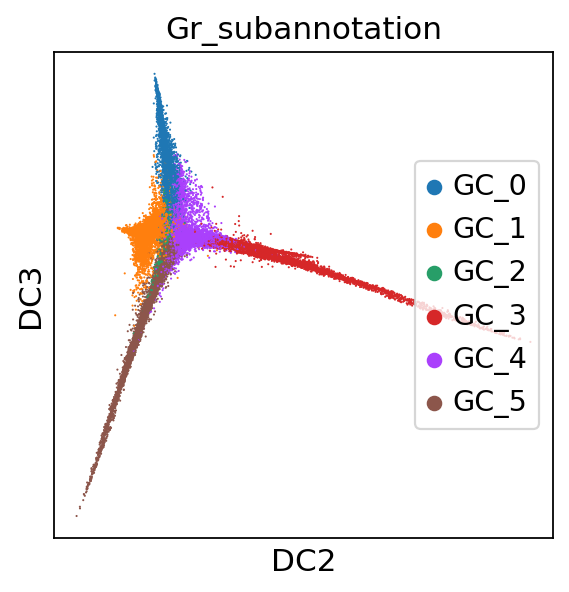

In [11]:
sc.pl.embedding(
    adata_a,
    basis="diffmap",
    color=['Gr_subannotation'],
    legend_loc="right",
    components=["2, 3"],
)

In [13]:
## 定义起点细胞
GC_mask = np.isin(adata_a.obs['Gr_subannotation'], ['GC_5'])
GC_min_stem_id = np.argmin(adata_a.obsm['X_diffmap_'][GC_mask, 1])
print(GC_min_stem_id)
GC_root_id=np.arange(len(GC_mask))[GC_mask][GC_min_stem_id]
print(GC_root_id)

5585
26290


In [14]:
# 计算DPT值
adata_a.uns['iroot'] = GC_root_id
sc.tl.dpt(adata_a,n_dcs=30,n_branchings=0)

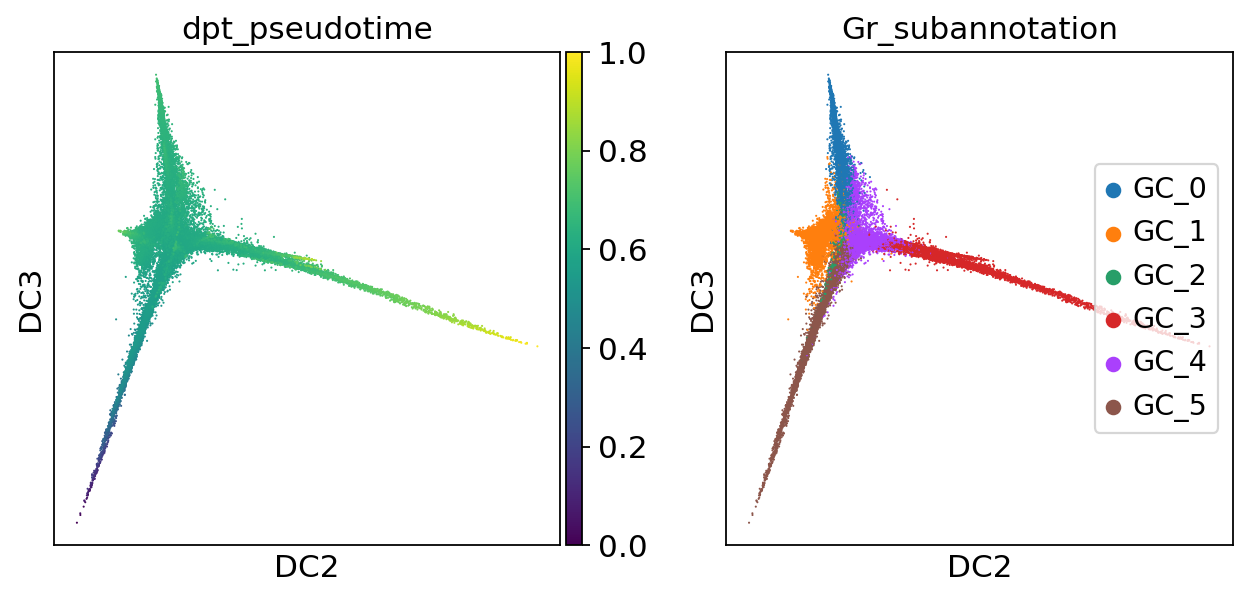

In [15]:
sc.pl.embedding(
    adata_a,
    basis="diffmap",
    color=['dpt_pseudotime','Gr_subannotation'],
    legend_loc="right",
    components=["2, 3"],
)

In [16]:
#### paga算法推断
sc.tl.paga(adata_a,groups='Gr_subannotation')

In [28]:
adata_a.write('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

#### 读入数据

In [2]:
adata_a=sc.read_h5ad('./10_cytotrace2_拟时序分析/10_after_hb_Gr_subanndata.h5ad')

In [3]:
adata_a

AnnData object with n_obs × n_vars = 33475 × 18144
    obs: 'sample', 'n_genes', 'group', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'S_score', 'G2M_score', 'phase', 'bbknn_leiden_0.5', 'harmony_leiden_0.5', 'harmony_leiden_0.2', 'Major_annotation', 'doublet_score', 'predicted_doublet', 'd_harmony_leiden_0.2', 'Major_annotation_d', 'Gr_subannotation', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'leiden_0.6', 'leiden_0.7', 'leiden_0.8', 'leiden_0.9', 'leiden_1.0', 'dpt_pseudotime'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variabl

In [4]:
import omicverse as ov

In [5]:
ov.utils.cal_paga(adata_a,use_time_prior='dpt_pseudotime',vkey='paga',
                 groups='Gr_subannotation')

running PAGA using priors: ['dpt_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


In [7]:
adata_a.uns['paga']

{'connectivities': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 28 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 5 stored elements in Compressed Sparse Row format>,
 'groups': 'Gr_subannotation',
 'pos': array([[ 0.94822562, 11.44954205],
        [-2.97202444,  7.65625668],
        [ 1.93306363,  7.98005009],
        [ 8.70613098,  3.40580249],
        [ 4.38298702,  6.16006374],
        [-0.02275543,  2.63852406]]),
 'transitions_confidence': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 5 stored elements in Compressed Sparse Column format>,
 'threshold': 0.018077513039143116}

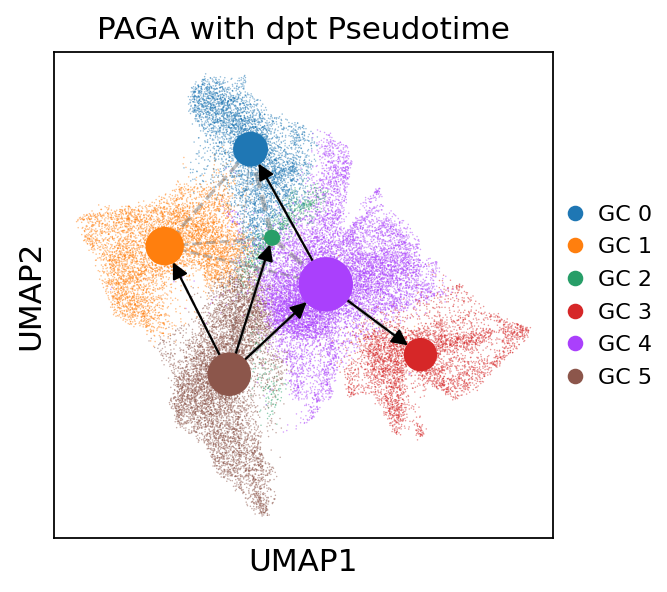

In [12]:
scv.pl.paga(adata_a,basis='umap'
           #,threshold=0.005
            ,node_size_scale=1.5
            ,min_edge_width=1
    ,edge_width_scale=2
    ,node_size_power=1
    ,add_pos=True,
    title='PAGA with dpt Pseudotime'
            ,frameon=True
        ,legend_fontsize=10
        , layout='fr'
        ,labels=None
            ,show=False
            ,figsize=(4,4)
           )

### 保存为pdf
plt.savefig("./figures/10_PAGA_dpt_plots.pdf", format="pdf", bbox_inches='tight')

#### monocle3 

##### 第一步在R中推断除monocle3假时间

##### 读入monocle3假时间

In [13]:
monocle3_pseudotime=pd.read_csv('./10_cytotrace2_拟时序分析/10_gr_monocle3_pseudotime.csv',index_col=0)
monocle3_pseudotime

,monocle3_pseudotime
GSM8302650_AAACCCAAGGCAATGC-1-GSM8302650,22.869792
GSM8302650_AAACCCACATCGCTGG-1-GSM8302650,34.825380
GSM8302650_AAACCCAGTATGAGAT-1-GSM8302650,9.257256
GSM8302650_AAACCCAGTTTAGACC-1-GSM8302650,31.145866
GSM8302650_AAACGAAAGATGTTGA-1-GSM8302650,14.777969
...,...
GSM8302655_TTTGTTGAGCGGACAT-1-GSM8302655,36.577004
GSM8302655_TTTGTTGAGGGAACAA-1-GSM8302655,9.505513
GSM8302655_TTTGTTGCACGGTGTC-1-GSM8302655,39.601026
GSM8302655_TTTGTTGGTGTTATCG-1-GSM8302655,36.549271


In [14]:
adata_a.obs_names.equals(monocle3_pseudotime.index)

True

In [15]:
adata_a.obs['monocle3_pseudotime']=monocle3_pseudotime

In [16]:
#### PAGA
ov.utils.cal_paga(adata_a,use_time_prior='monocle3_pseudotime',vkey='paga',
                 groups='Gr_subannotation')

running PAGA using priors: ['monocle3_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


In [18]:
adata_a.uns['paga']

{'connectivities': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 28 stored elements in Compressed Sparse Row format>,
 'connectivities_tree': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 5 stored elements in Compressed Sparse Row format>,
 'groups': 'Gr_subannotation',
 'pos': array([[ 0.94822562, 11.44954205],
        [-2.97202444,  7.65625668],
        [ 1.93306363,  7.98005009],
        [ 8.70613098,  3.40580249],
        [ 4.38298702,  6.16006374],
        [-0.02275543,  2.63852406]]),
 'transitions_confidence': <6x6 sparse matrix of type '<class 'numpy.float64'>'
 	with 5 stored elements in Compressed Sparse Column format>,
 'threshold': 0.01995117645169261}

In [ ]:
scv.pl.paga(adata_a,basis='umap'
           #,threshold=0.03
            ,node_size_scale=1.5
            ,min_edge_width=1
    ,edge_width_scale=2
    ,node_size_power=1
    ,add_pos=True,
    title='PAGA with monocle3 Pseudotime'
    ,frameon=True
    ,legend_fontsize=10
    , layout='fr'
    ,labels=None
    ,show=False
    ,figsize=(4,4)
           )

### 保存为pdf
plt.savefig("./figures/10_PAGA_monocle3_plots.pdf", format="pdf", bbox_inches='tight')

#### Palantir  换到单独脚本跑  10_2  cytotrace2环境  cytotrace2包和Palantir包在一起

In [51]:
import palantir

In [52]:
### PCA降维
adata_pr=adata_a
har_projections = pd.DataFrame(adata_pr.obsm['X_pca_harmony'], index=adata_pr.obs_names) #去批次映射
dm_res = palantir.utils.run_diffusion_maps(har_projections, n_components=10)
ms_data = palantir.utils.determine_multiscale_space(dm_res)

In [54]:
## 定义起点细胞
GC0_mask = np.isin(adata_a.obs['Gr_subannotation'], ['GC_0'])
GC0_min_stem_id = np.argmax(adata_a.obsm['X_diffmap_'][GC0_mask, 1])
print(GC0_min_stem_id)
GC0_root_id=np.arange(len(GC0_mask))[GC0_mask][GC0_min_stem_id]
print(GC0_root_id)

3825
31006


In [76]:
## 定义分化终点细胞
## 设定终末细胞 利用先验知识
terminal_cells = {
   har_projections.index[adata_a.obs['Gr_subannotation']  == 'GC_3'][0]: "Branch2",
    har_projections.index[adata_a.obs['Gr_subannotation']  == 'GC_5'][0]: "Branch1"
 # "BIOKEY_24_Pre_TACCTATAGGCAATTA-1": "Tumor_0"
  #"HS-BM-P1-cells-1_CTTACCGCATCTACGA-1": "CLP",
  #"HS-BM-P1-cells-2_ACAGCTAGTAAGGATT-1": "Ery",
  #"HS-BM-P1-cells-1_CGTCACTTCAGGCGAA-1": "Mega",
  #"HS-BM-P1-cells-1_TTAGTTCTCGGACAAG-1": "Mono"
}

In [77]:
### 自由推断

early_cell = har_projections.index.tolist()[GC0_root_id]
terminal_cell=terminal_cells
pr_res = palantir.core.run_palantir(ms_data
                                    , early_cell=early_cell
                                    , use_early_cell_as_start=False #自动选择试试
                                   ,n_jobs=5
                                    ,terminal_states=terminal_cell
                                    , num_waypoints=500, knn=30)

Sampling and flocking waypoints...
Time for determining waypoints: 0.07404727935791015 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 1.521163316567739 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9995
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [93]:
# 创建一个新的列名列表，根据 terminal_cell 字典进行映射
pr_res.branch_probs.columns= [terminal_cell[col] for col in pr_res.branch_probs.columns]
for i in pr_res.branch_probs.columns.tolist():
    adata_a.obs[i] = pr_res.branch_probs[i]
adata_a.obsm['palantir_fate_probabilities']=pr_res.branch_probs

In [79]:

### 保存数据
adata_a.obs['Palantir_pseudotime'] = pr_res.pseudotime
adata_a.obs["Palantir_DP"] = pr_res.entropy


In [101]:
#### PAGA
ov.utils.cal_paga(adata_a,use_time_prior='Palantir_pseudotime',vkey='paga',
                 groups='Gr_subannotation')

running PAGA using priors: ['Palantir_pseudotime']
    finished
added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns)
    'paga/transitions_confidence', velocity transitions (adata.uns)


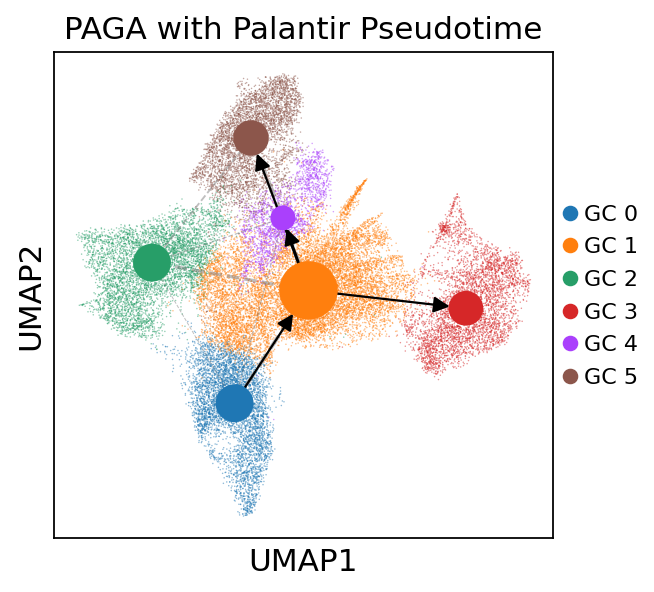

In [102]:
scv.pl.paga(adata_a,basis='umap'
           #,threshold=0.03
            ,node_size_scale=1.5
            ,min_edge_width=1
    ,edge_width_scale=2
    ,node_size_power=1
    ,add_pos=True,
    title='PAGA with Palantir Pseudotime'
    ,frameon=True
    ,legend_fontsize=10
    , layout='fr'
    ,labels=None
    ,show=False
    ,figsize=(4,4)
           )

### 保存为pdf
plt.savefig("./figures/10_PAGA_Palantir_plots.pdf", format="pdf", bbox_inches='tight')

In [94]:
## 选择分支
branch_masks=palantir.presults.select_branch_cells(adata_a,pseudo_time_key='Palantir_pseudotime',save_as_df=True)

In [110]:
# 定义列名（columns）和行名（index）
column_names = ['Branch2_cells','Branch1_cells']
row_names = adata_a.obs_names

# 转换为 DataFrame
branch_masks_df = pd.DataFrame(branch_masks, columns=column_names, index=row_names)

adata_a.obs[['Branch2_cells','Branch1_cells']]=branch_masks_df

In [106]:
#### 保存分支可能性数据
adata_a.obs[['Branch2','Branch1']]=adata_a.obsm['palantir_fate_probabilities']

In [111]:
### 保存数据
adata_a.obs.to_csv('./10_cytotrace2_拟时序分析/pseudotime_res_all.csv',index=True)

In [118]:
### 导出umap坐标
adata_a.obsm['X_umap']

# 定义列名（columns）和行名（index）
column_names = ['UMAP_1','UMAP_2']
row_names = adata_a.obs_names

# 转换为 DataFrame
umap_df = pd.DataFrame(adata_a.obsm['X_umap'], columns=column_names, index=row_names)

### 保存数据
branch_masks_df.to_csv('./10_cytotrace2_拟时序分析/10_UMAP_coords.csv',index=True)

array([[5.3556414, 7.237778 ],
       [3.3638628, 3.395223 ],
       [3.2560306, 4.546152 ],
       ...,
       [5.397869 , 9.141803 ],
       [5.481725 , 9.290509 ],
       [5.541056 , 9.2591915]], dtype=float32)

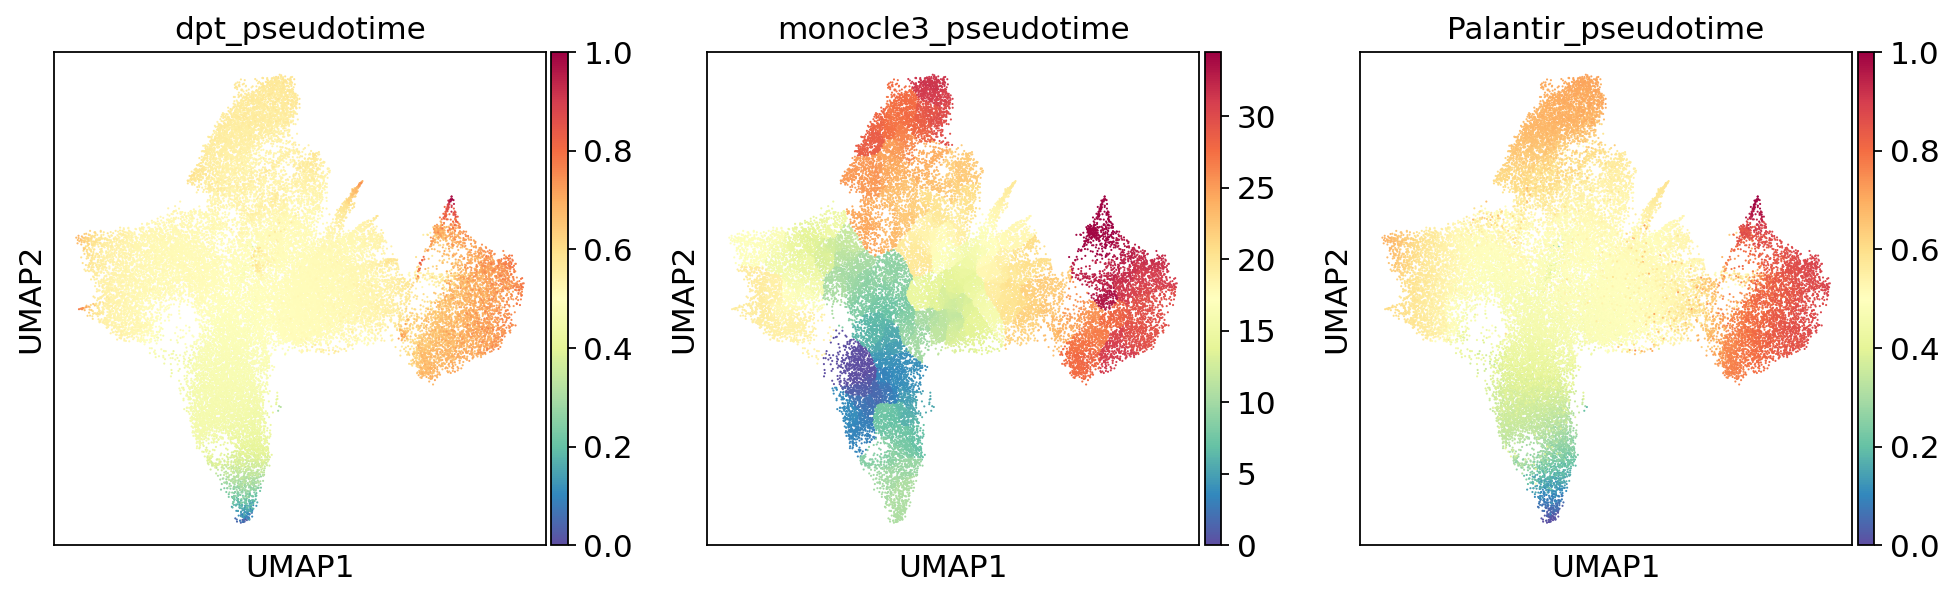

In [115]:
sc.pl.umap(adata_a, color=[ 'dpt_pseudotime','monocle3_pseudotime','Palantir_pseudotime']
               ,frameon=True
           ,legend_fontsize=10
           ,show=False
            ,cmap='Spectral_r'
               )
### 保存为pdf
plt.savefig("./figures/10_three_pseudotime.pdf", format="pdf", bbox_inches='tight')